# Simple Moving Average and Exponential Moving Average

This notebook compares two common trend-following indicators, the simple moving average (SMA) and the exponential moving average (EMA), on two US equity indices: the S&P 500 (`^GSPC`) and the S&P MidCap 400 (`^MID`). It walks through how each indicator is calculated, plots them against the raw closing price, and then looks at how the EMA has grown over time.

Nothing in this notebook implements an actual trading strategy with buy and sell signals, such as a moving-average crossover. The "returns" and "investment returns" sections later in the notebook track the growth of the EMA-smoothed price series itself, not the returns of a strategy that trades on it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import date
import warnings
warnings.filterwarnings("ignore")

ticker_1 = '^GSPC'  # S&P 500 Index
ticker_2 = '^MID'  # S&P MidCap 400 Index

gspc = yf.download('^GSPC', start='2013-01-01', end=date.today().strftime('%Y-%m-%d'))
mid = yf.download('^MID', start='2013-01-01', end=date.today().strftime('%Y-%m-%d'))

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


This cell downloads daily price history for the S&P 500 and the S&P MidCap 400 from Yahoo Finance, starting January 1, 2013 through today. `^GSPC` is the Yahoo Finance ticker for the S&P 500 index, and `^MID` is the ticker for the S&P MidCap 400 index. Both are price indices, not individual stocks, so there is no single company behind the ticker. `warnings.filterwarnings("ignore")` is used to suppress the routine deprecation warnings `yfinance` and `pandas` sometimes print, but note that this also hides genuinely useful warnings, so it is worth removing temporarily if something looks wrong later in the notebook.

## Simple Moving Average

Simple moving average = (Sum of data points) / (Number of data points)

For example, if you want to calculate the 50-day SMA, you sum up the closing prices of the last 50 trading days and divide the sum by 50. As each new day of data arrives, the window slides forward by one day, dropping the oldest price and adding the newest one, which is exactly what `pandas.Series.rolling(window=n).mean()` does below.

Because every price in the window is weighted equally, the SMA reacts more slowly to recent price changes than the EMA does, which is covered next. That slower reaction is good when the goal is to filter out short-term noise and focus on the broader trend, but it also means the SMA lags further behind sharp reversals.

In [2]:
period_50 = 50
period_100 = 100

gspc['SMA_50'] = gspc['Close'].rolling(window=period_50).mean()
gspc['SMA_100'] = gspc['Close'].rolling(window=period_100).mean()

mid['SMA_50'] = mid['Close'].rolling(window=period_50).mean()
mid['SMA_100'] = mid['Close'].rolling(window=period_100).mean()

The `50_day` and `100_day` windows chosen here are two of the most commonly used SMA lengths in technical analysis. The 50-day SMA is typically read as a medium-term trend, and the 100-day (or 200-day, in other conventions) SMA is read as a longer-term trend. Because a rolling mean needs a full window of prior data before it can compute a value, the first 49 rows of `SMA_50` and the first 99 rows of `SMA_100` will be `NaN`.

<Figure size 2000x800 with 0 Axes>

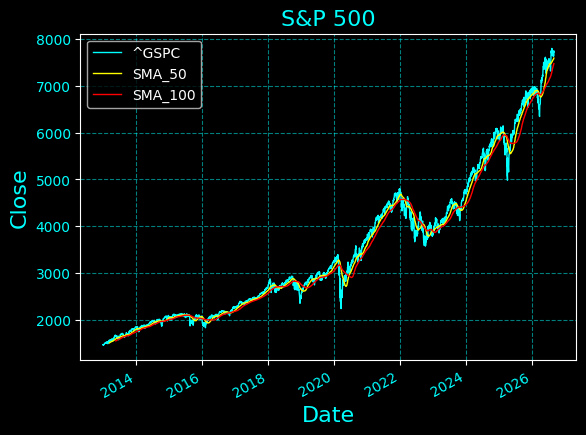

In [3]:
plt.style.use('dark_background')
plt.figure(figsize=(20, 8), linewidth=6)
gspc['Close'].plot(color="cyan", linewidth=1)
gspc['SMA_50'].plot(color="yellow", linewidth=1)
gspc['SMA_100'].plot(color="red", linewidth=1)
plt.xlabel('Date', fontsize=16, color="cyan")
plt.ylabel('Close', fontsize=16, color="cyan")
plt.title('S&P 500', fontsize=16, color="cyan")
plt.grid(linestyle="--"
, color="cyan", alpha=0.5)
plt.xticks(color="cyan")
plt.yticks(color="cyan")
plt.legend()
plt.show()

<Figure size 2000x800 with 0 Axes>

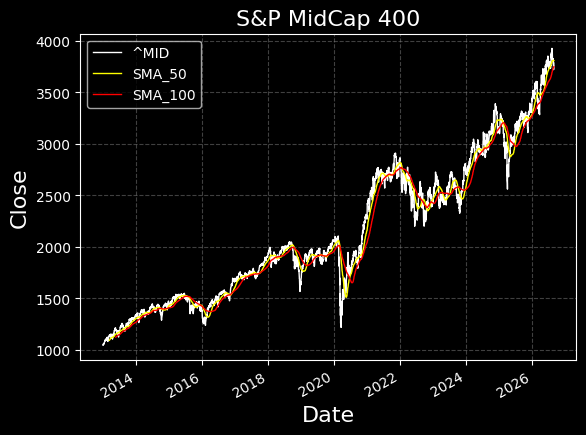

In [4]:
plt.style.use('dark_background')
plt.figure(figsize=(20, 8), linewidth=6)
mid['Close'].plot(color="white", linewidth=1)
mid['SMA_50'].plot(color="yellow", linewidth=1)
mid['SMA_100'].plot(color="red", linewidth=1)
plt.xlabel('Date', fontsize=16, color="white")
plt.ylabel('Close', fontsize=16, color="white")
plt.title('S&P MidCap 400', fontsize=16, color="white")
plt.grid(linestyle="--"
, color="grey", alpha=0.5)
plt.legend()
plt.show()

## Exponential Moving Average

Exponential moving average = (Closing price - previous EMA) * (Smoothing Factor) + (Previous EMA)

The smoothing factor determines the weight assigned to the current price relative to the accumulated history of previous prices baked into the previous EMA value.

The smoothing factor is calculated using the following formula:
Smoothing Factor = (2 / (Number of periods + 1))

Unlike the SMA, the EMA weights recent prices more heavily than older ones, and that weight decays exponentially the further back in time you go, which is where the name comes from. This makes the EMA respond faster to new price information than an SMA of the same window length, at the cost of being more sensitive to short-term noise. `pandas.Series.ewm(span=n, adjust=False).mean()` implements this recursive formula directly: each new EMA value depends only on the current price and the immediately preceding EMA value, rather than on the full window of raw prices the way the SMA does.

<Figure size 2000x800 with 0 Axes>

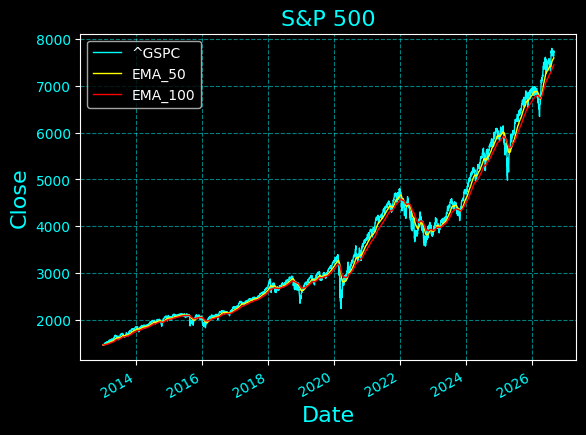

In [5]:
ema_period_50 = 50
ema_period_100 = 100

gspc['EMA_50'] = gspc['Close'].ewm(span=ema_period_50, adjust=False).mean()
gspc['EMA_100'] = gspc['Close'].ewm(span=ema_period_100, adjust=False).mean()

mid['EMA_50'] = mid['Close'].ewm(span=ema_period_50, adjust=False).mean()
mid['EMA_100'] = mid['Close'].ewm(span=ema_period_100, adjust=False).mean()

plt.style.use('dark_background')
plt.figure(figsize=(20, 8), linewidth=6)
gspc['Close'].plot(color="cyan", linewidth=1)
gspc['EMA_50'].plot(color="yellow", linewidth=1)
gspc['EMA_100'].plot(color="red", linewidth=1)
plt.xlabel('Date', fontsize=16, color="cyan")
plt.ylabel('Close', fontsize=16, color="cyan")
plt.title('S&P 500', fontsize=16, color="cyan")
plt.grid(linestyle="--"
, color="cyan", alpha=0.5)
plt.xticks(color="cyan")
plt.yticks(color="cyan")
plt.legend()
plt.show()

<Figure size 2000x800 with 0 Axes>

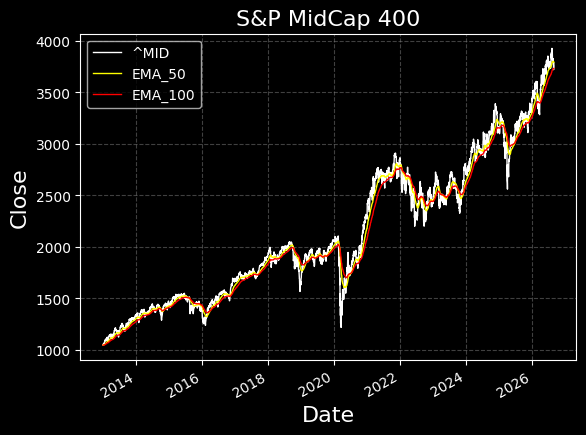

In [6]:
plt.style.use('dark_background')
plt.figure(figsize=(20, 8), linewidth=6)
mid['Close'].plot(color="white", linewidth=1)
mid['EMA_50'].plot(color="yellow", linewidth=1)
mid['EMA_100'].plot(color="red", linewidth=1)
plt.xlabel('Date', fontsize=16, color="white")
plt.ylabel('Close', fontsize=16, color="white")
plt.title('S&P MidCap 400', fontsize=16, color="white")
plt.grid(linestyle="--"
, color="grey", alpha=0.5)
plt.legend()
plt.show()

## SMA and EMA Comparison

The charts in this section overlay the raw closing price, both SMAs, and both EMAs on the same axes so the two indicator families can be compared directly. Since the EMA weights recent prices more heavily, it should visibly hug the closing price more tightly than the SMA of the same length, especially around sharp moves. Each index gets a full-history view and a trailing two-year view (`tail(252*2)`, using the standard approximation of 252 trading days per year) so that recent behavior is easier to see without losing the long-run context.

### S&P 500

<Figure size 2000x800 with 0 Axes>

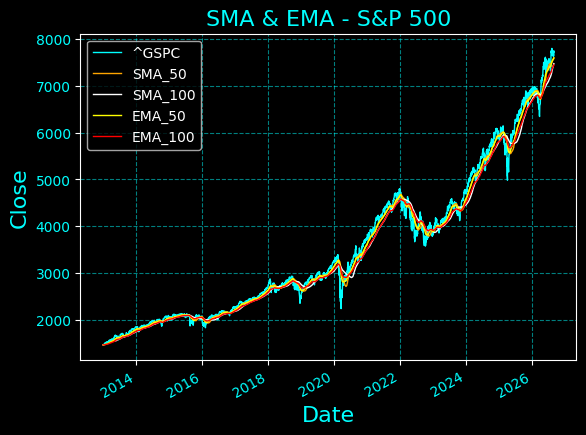

In [7]:
plt.style.use('dark_background')
plt.figure(figsize=(20, 8), linewidth=6)
gspc['Close'].plot(color="cyan", linewidth=1)
gspc['SMA_50'].plot(color="orange", linewidth=1)
gspc['SMA_100'].plot(color="white", linewidth=1)
gspc['EMA_50'].plot(color="yellow", linewidth=1)
gspc['EMA_100'].plot(color="red", linewidth=1)
plt.xlabel('Date', fontsize=16, color="cyan")
plt.ylabel('Close', fontsize=16, color="cyan")
plt.title('SMA & EMA - S&P 500', fontsize=16, color="cyan")
plt.grid(linestyle="--"
, color="cyan", alpha=0.5)
plt.xticks(color="cyan")
plt.yticks(color="cyan")
plt.legend()
plt.show()

<Figure size 2000x800 with 0 Axes>

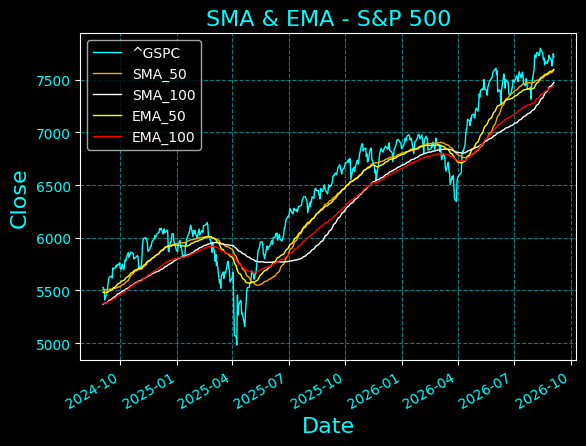

In [8]:
plt.style.use('dark_background')
plt.figure(figsize=(20, 8), linewidth=6)
gspc['Close'].tail(252*2).plot(color="cyan", linewidth=1)
gspc['SMA_50'].tail(252*2).plot(color="orange", linewidth=1)
gspc['SMA_100'].tail(252*2).plot(color="white", linewidth=1)
gspc['EMA_50'].tail(252*2).plot(color="yellow", linewidth=1)
gspc['EMA_100'].tail(252*2).plot(color="red", linewidth=1)
plt.xlabel('Date', fontsize=16, color="cyan")
plt.ylabel('Close', fontsize=16, color="cyan")
plt.title('SMA & EMA - S&P 500', fontsize=16, color="cyan")
plt.grid(linestyle="--"
, color="cyan", alpha=0.5)
plt.xticks(color="cyan")
plt.yticks(color="cyan")
plt.legend()
plt.show()

### S&P MidCap 400

<Figure size 2000x800 with 0 Axes>

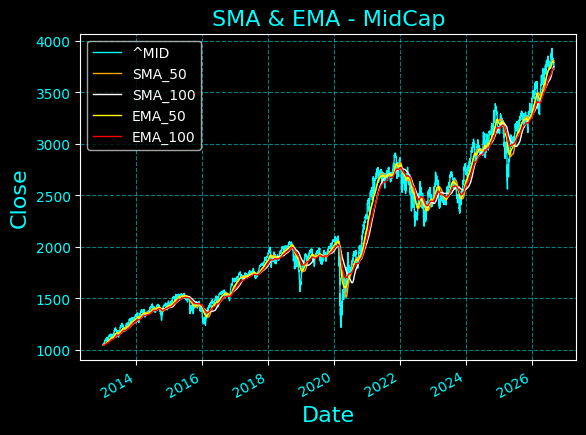

In [9]:
plt.style.use('dark_background')
plt.figure(figsize=(20, 8), linewidth=6)
mid['Close'].plot(color="cyan", linewidth=1)
mid['SMA_50'].plot(color="orange", linewidth=1)
mid['SMA_100'].plot(color="white", linewidth=1)
mid['EMA_50'].plot(color="yellow", linewidth=1)
mid['EMA_100'].plot(color="red", linewidth=1)
plt.xlabel('Date', fontsize=16, color="cyan")
plt.ylabel('Close', fontsize=16, color="cyan")
plt.title('SMA & EMA - MidCap', fontsize=16, color="cyan")
plt.grid(linestyle="--"
, color="cyan", alpha=0.5)
plt.xticks(color="cyan")
plt.yticks(color="cyan")
plt.legend()
plt.show()

<Figure size 2000x800 with 0 Axes>

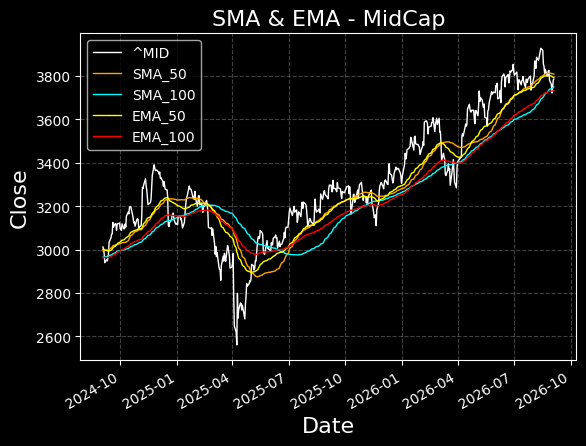

In [10]:
plt.style.use('dark_background')
plt.figure(figsize=(20, 8), linewidth=6)
mid['Close'].tail(252*2).plot(color="white", linewidth=1)
mid['SMA_50'].tail(252*2).plot(color="orange", linewidth=1)
mid['SMA_100'].tail(252*2).plot(color="cyan", linewidth=1)
mid['EMA_50'].tail(252*2).plot(color="yellow", linewidth=1)
mid['EMA_100'].tail(252*2).plot(color="red", linewidth=1)
plt.xlabel('Date', fontsize=16, color="white")
plt.ylabel('Close', fontsize=16, color="white")
plt.title('SMA & EMA - MidCap', fontsize=16, color="white")
plt.grid(linestyle="--"
, color="grey", alpha=0.5)
plt.legend()
plt.show()

## Returns

This section computes the percent change of the EMA series itself from one day to the next, not the percent change of the raw closing price. Because the EMA is a smoothed version of price, its day-over-day percent change is a smoothed version of the daily return, with the smoothing more pronounced for the 100-day EMA than the 50-day EMA. This is a useful way to see how the underlying trend is accelerating or decelerating, but it should not be read as the actual day-to-day return an investor holding the index would have experienced. That figure would come from `Close.pct_change()` on the raw price series instead.

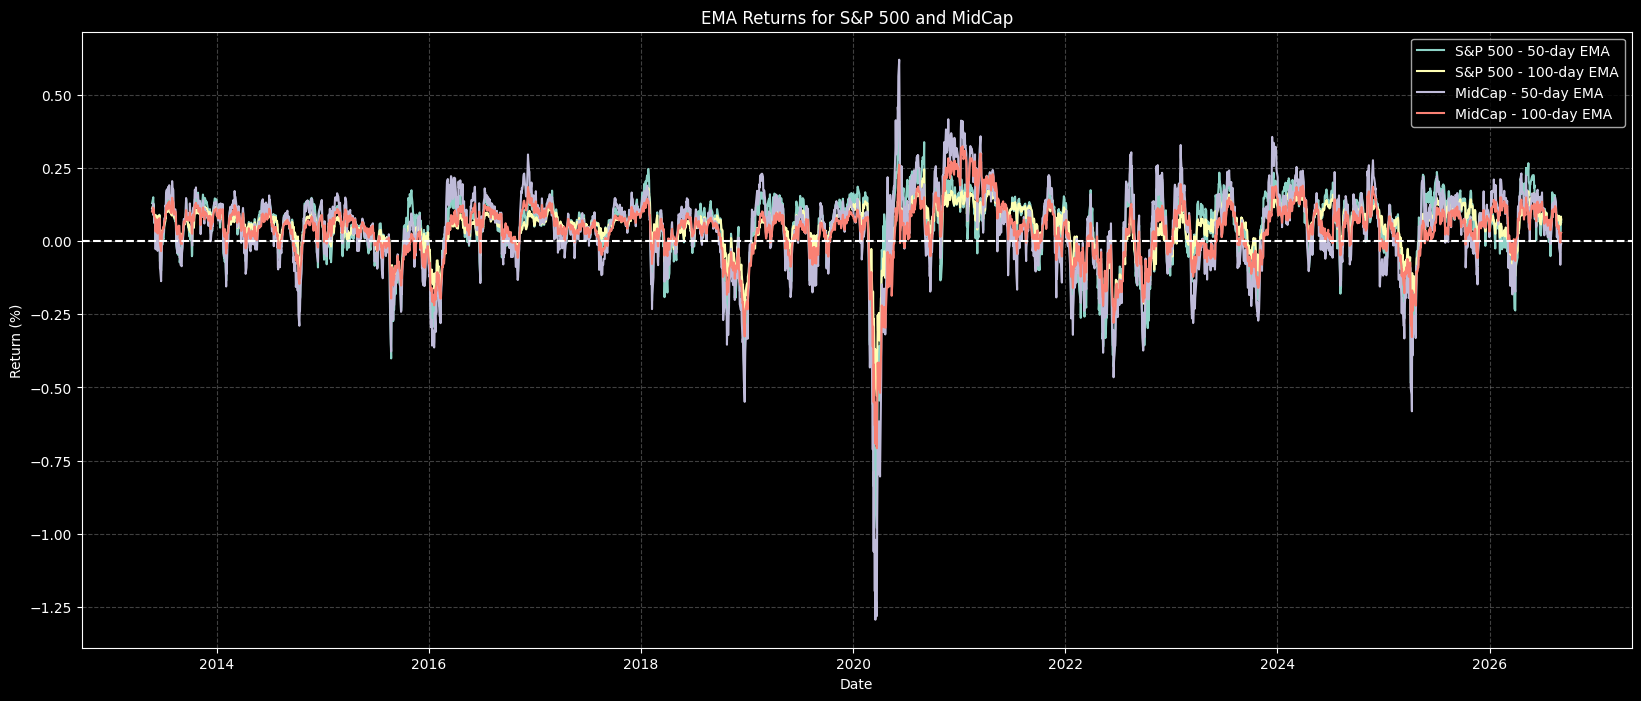

In [11]:
gspc['EMA_50_Returns'] = gspc['EMA_50'].pct_change() * 100
gspc['EMA_100_Returns'] = gspc['EMA_100'].pct_change() * 100

mid['EMA_50_Returns'] = mid['EMA_50'].pct_change() * 100
mid['EMA_100_Returns'] = mid['EMA_100'].pct_change() * 100

gspc.dropna(inplace=True)
mid.dropna(inplace=True)

plt.style.use('dark_background')
plt.figure(figsize=(20, 8), linewidth=6)
plt.plot(gspc.index, gspc['EMA_50_Returns'], label='S&P 500 - 50-day EMA')
plt.plot(gspc.index, gspc['EMA_100_Returns'], label='S&P 500 - 100-day EMA')
plt.plot(mid.index, mid['EMA_50_Returns'], label='MidCap - 50-day EMA')
plt.plot(mid.index, mid['EMA_100_Returns'], label='MidCap - 100-day EMA')
plt.xlabel('Date')
plt.ylabel('Return (%)')
plt.title('EMA Returns for S&P 500 and MidCap')
plt.axhline(0, linestyle="--")
plt.legend()
plt.grid(linestyle="--"
, color="grey", alpha=0.5)
plt.show()

## Cumulative Returns

This section compounds the daily EMA returns from the previous section into a cumulative growth series using `cumprod()`. Because the underlying daily figures are the smoothed EMA returns rather than raw price returns, the result is best read as the cumulative growth of the EMA-smoothed price line, not as the return of a strategy that actually traded in or out of the index. There are no buy or sell signals anywhere in this notebook, so nothing here reflects a backtested trading strategy.

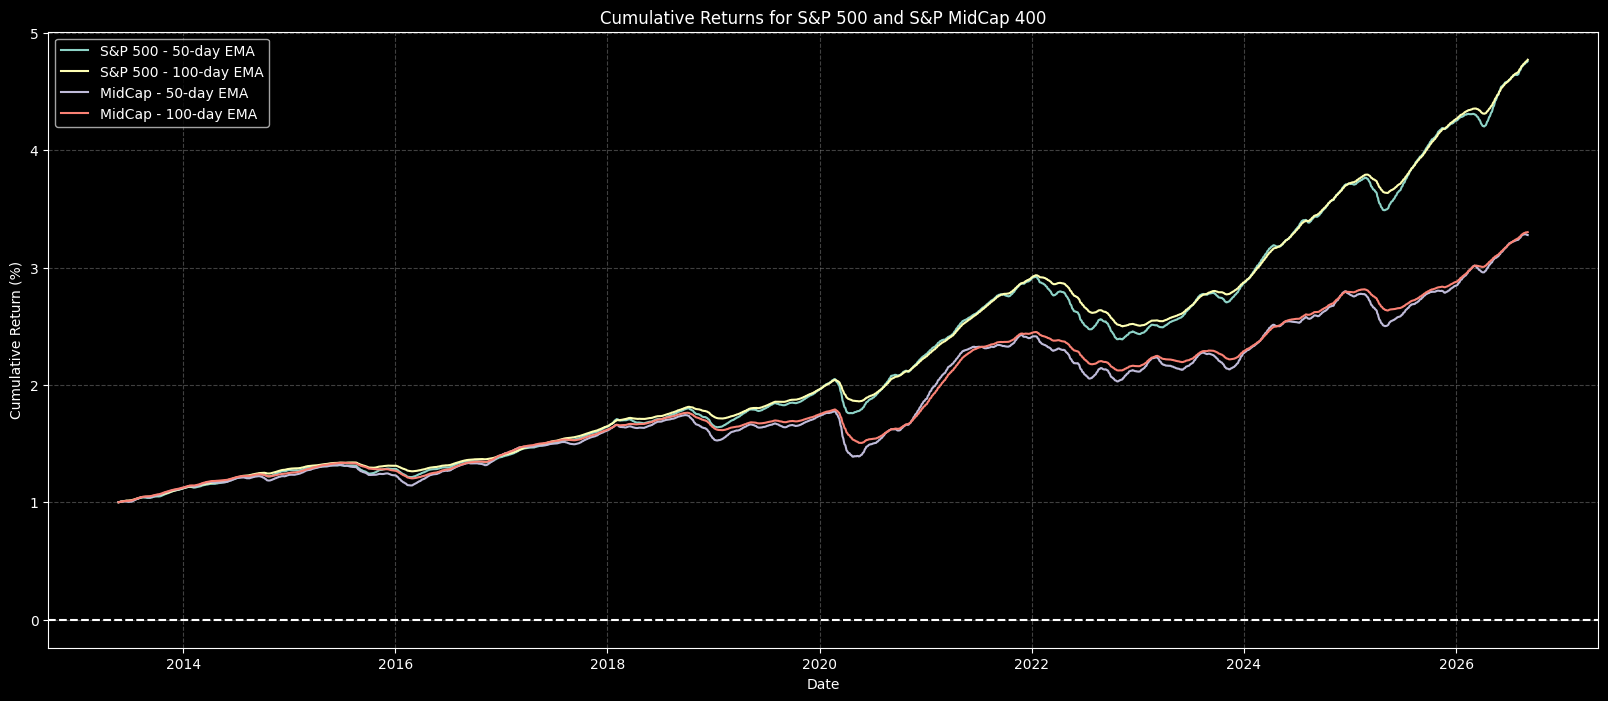

In [12]:
gspc['EMA_50_Cumulative_Returns'] = (1 + gspc['EMA_50_Returns'] / 100).cumprod()
gspc['EMA_100_Cumulative_Returns'] = (1 + gspc['EMA_100_Returns'] / 100).cumprod()
mid['EMA_50_Cumulative_Returns'] = (1 + mid['EMA_50_Returns'] / 100).cumprod()
mid['EMA_100_Cumulative_Returns'] = (1 + mid['EMA_100_Returns'] / 100).cumprod()

gspc.dropna(inplace=True)
mid.dropna(inplace=True)

plt.style.use('dark_background')
plt.figure(figsize=(20, 8), linewidth=6)
plt.plot(gspc.index, gspc['EMA_50_Cumulative_Returns'], label='S&P 500 - 50-day EMA')
plt.plot(gspc.index, gspc['EMA_100_Cumulative_Returns'], label='S&P 500 - 100-day EMA')
plt.plot(mid.index, mid['EMA_50_Cumulative_Returns'], label='MidCap - 50-day EMA')
plt.plot(mid.index, mid['EMA_100_Cumulative_Returns'], label='MidCap - 100-day EMA')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.title('Cumulative Returns for S&P 500 and S&P MidCap 400')
plt.axhline(0, linestyle="--")
plt.legend()
plt.grid(linestyle="--"
, color="grey", alpha=0.5)
plt.show()

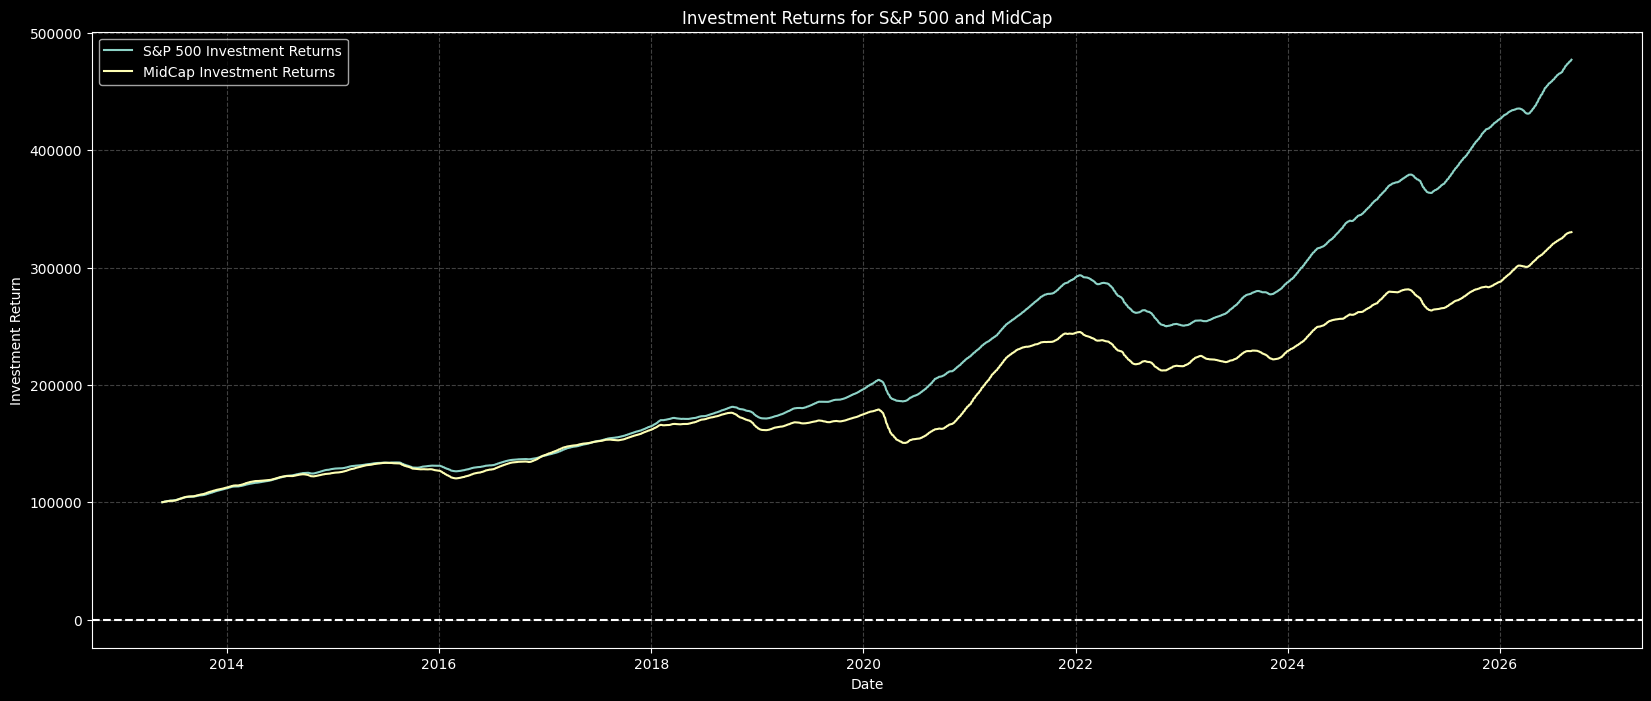

In [13]:
Initial_Investment = 100_000

gspc['Investment_Returns'] = gspc['EMA_100_Cumulative_Returns'] * Initial_Investment
mid['Investment_Returns'] = mid['EMA_100_Cumulative_Returns'] * Initial_Investment

gspc.dropna(inplace=True)
mid.dropna(inplace=True)

plt.style.use('dark_background')
plt.figure(figsize=(20, 8), linewidth=6)
plt.plot(gspc.index, gspc['Investment_Returns'], label='S&P 500 Investment Returns')
plt.plot(mid.index, mid['Investment_Returns'], label='MidCap Investment Returns')
plt.xlabel('Date')
plt.ylabel('Investment Return')
plt.title('Investment Returns for S&P 500 and MidCap')
plt.axhline(0, linestyle="--")
plt.legend()
plt.grid(linestyle="--"
, color="grey", alpha=0.5)
plt.show()

The chart above applies the same cumulative EMA growth series to a hypothetical starting balance of $100,000. As with the cumulative returns section, this shows what a $100,000 balance would have grown to if it tracked the 100-day EMA's smoothed growth rate exactly, not what an actual investment in either index would have returned, and not the result of any trading rule. For a genuine buy-and-hold comparison, the same calculation could be repeated using `Close.pct_change()` on the raw price series instead of the EMA return columns.

In [14]:
gspc_final_returns = gspc['Investment_Returns'].iloc[-1] - Initial_Investment
mid_final_returns = mid['Investment_Returns'].iloc[-1] - Initial_Investment

gspc.dropna(inplace=True)
mid.dropna(inplace=True)

print('Final Investment Returns:')
print(f'S&P 500: ${gspc_final_returns:,.2f}')
print(f'MidCap: ${mid_final_returns:,.2f}')

Final Investment Returns:
S&P 500: $377,010.80
MidCap: $230,144.76
